# Análisis espacial comparativo: Gran Santiago y Concepción

Este notebook prepara capas espaciales, construye grillas de 250 × 250 m, resume actividad comercial y transporte, integra población del Censo 2024 y compara los resultados de ambas ciudades. Ejecuta las celdas en orden.

## 1. Preparacion y alcance

Gran Santiago se delimita mediante la union de 39 comunas.

Gran Concepcion comprende Concepcion, Talcahuano, Hualpen, San Pedro de la Paz, Chiguayante y Penco. Los totales de poblacion se calculan dentro de estas mascaras y usando las manzanas censales disponibles. Las fuentes se leen desde `data/raw` y los CSV generados se guardan en `data/processed`.

In [1]:
import os

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from shapely.geometry import Point, box

ruta_raw = os.path.join("data", "raw")
ruta_processed = os.path.join("data", "processed")
os.makedirs(ruta_processed, exist_ok=True)

ruta_gpkg = os.path.join(ruta_raw, "chile.gpkg")
ruta_censo = os.path.join(ruta_raw, "Cartografia_censo2024_Pais_Manzanas.parquet")
ruta_comunas = os.path.join(ruta_raw, "Cartografia_censo2024_Pais_Comunal.parquet")
tamano_celda = 250

for ruta_archivo, descripcion in [
    (ruta_gpkg, "el GeoPackage"),
    (ruta_censo, "las manzanas censales"),
    (ruta_comunas, "la cartografía comunal"),
]:
    if not os.path.isfile(ruta_archivo):
        raise FileNotFoundError(f"No se encontró {descripcion}: {ruta_archivo}")

print("Archivos de entrada encontrados.")

Archivos de entrada encontrados.


In [2]:
import unicodedata

comunas = gpd.read_parquet(ruta_comunas)
if "COMUNA" not in comunas.columns:
    raise KeyError("La cartografia comunal no contiene la columna 'COMUNA'.")
if comunas.crs is None:
    raise ValueError("La cartografia comunal no tiene un CRS definido.")


def normalizar_nombre(nombre):
    return (
        unicodedata.normalize("NFKD", nombre)
        .encode("ascii", "ignore")
        .decode("ascii")
        .strip()
        .upper()
    )


def crear_mascara_comunal(nombres, area):
    seleccion = comunas[
        comunas["comuna_normalizada"].isin(nombres)
    ].copy()
    encontradas = set(seleccion["comuna_normalizada"])
    faltantes = set(nombres) - encontradas
    if faltantes:
        raise ValueError(
            f"No se encontraron comunas para {area}: {sorted(faltantes)}"
        )
    geometria = seleccion.geometry.union_all()
    mascara = (
        gpd.GeoSeries([geometria], crs=seleccion.crs)
        .to_crs("EPSG:4326")
        .iloc[0]
    )
    return mascara, encontradas


comunas_gran_santiago = [
    "SANTIAGO", "CERRILLOS", "CERRO NAVIA", "CONCHALI", "EL BOSQUE",
    "ESTACION CENTRAL", "HUECHURABA", "INDEPENDENCIA", "LA CISTERNA",
    "LA FLORIDA", "LA GRANJA", "LA PINTANA", "LA REINA", "LAS CONDES",
    "LO BARNECHEA", "LO ESPEJO", "LO PRADO", "MACUL", "MAIPU", "NUNOA",
    "PEDRO AGUIRRE CERDA", "PENALOLEN", "PROVIDENCIA", "PUDAHUEL",
    "QUILICURA", "QUINTA NORMAL", "RECOLETA", "RENCA", "SAN JOAQUIN",
    "SAN MIGUEL", "SAN RAMON", "VITACURA", "PUENTE ALTO", "SAN BERNARDO",
    "PADRE HURTADO", "LAMPA", "SAN JOSE DE MAIPO", "COLINA", "PIRQUE",
]
comunas_gran_concepcion = [
    "CONCEPCION", "TALCAHUANO", "HUALPEN", "SAN PEDRO DE LA PAZ",
    "CHIGUAYANTE", "PENCO",
]
if len(comunas_gran_santiago) != 39 or len(set(comunas_gran_santiago)) != 39:
    raise ValueError("La lista de comunas de Gran Santiago debe contener 39 nombres unicos.")

comunas["comuna_normalizada"] = comunas["COMUNA"].map(normalizar_nombre)
mascara_gran_santiago, encontradas_santiago = crear_mascara_comunal(
    comunas_gran_santiago, "Gran Santiago"
)
mascara_gran_concepcion, encontradas_concepcion = crear_mascara_comunal(
    comunas_gran_concepcion, "Gran Concepcion"
)

CIUDADES = {
    "Gran Santiago": {
        "prefijo": "stgo",
        "crs_utm": "EPSG:32719",
        "mascara": mascara_gran_santiago,
    },
    f"Gran Concepci\u00f3n": {
        "prefijo": "ccp",
        "crs_utm": "EPSG:32718",
        "mascara": mascara_gran_concepcion,
    },
}

print(f"Mascaras listas: {len(encontradas_santiago)} comunas en Gran Santiago.")
print("Comunas incluidas en Gran Concepcion: " + ", ".join(sorted(encontradas_concepcion)))

Mascaras listas: 39 comunas en Gran Santiago.
Comunas incluidas en Gran Concepcion: CHIGUAYANTE, CONCEPCION, HUALPEN, PENCO, SAN PEDRO DE LA PAZ, TALCAHUANO


## 2. Extracción y preparación de capas

Para cada ciudad se extraen las mismas capas: Áreas residenciales, ví­as principales, transporte público y puntos de interés comerciales/equipamiento. Los archivos se guardan con prefijos `stgo` y `ccp` para distinguirlos.

Los puntos de interés combinan la capa de puntos (`gis_osm_pois_free`) y la de polígonos (`gis_osm_pois_a_free`), donde están los lugares dibujados como edificio. Cada polígono se reemplaza por su centroide y se descarta si contiene un punto de la misma categoría o si su `osm_id` ya está en la capa de puntos, para no contarlo dos veces.

Luego imprime los lugares agregados de gis_osm_pois_a_free y entre parentesis cuántos de esos son supermercados

In [3]:
CLASES_VIALES = ["primary", "secondary", "tertiary", "trunk"]
CLASES_TRANSPORTE = ["bus_stop", "bus_station", "station"]
CATEGORIAS_POI = [
    "supermarket", "convenience", "mall", "pharmacy", "marketplace",
    "school", "university", "college", "hospital", "clinic", "sports_centre",
]
CATEGORIAS_PREDICTORAS = [
    categoria for categoria in CATEGORIAS_POI if categoria != "supermarket"
]
CATEGORIAS_COMERCIALES = ["convenience", "mall", "pharmacy", "marketplace"]


def extraer_capas(config):
    prefijo = config["prefijo"]
    mascara = config["mascara"]

    usos_suelo = gpd.read_file(
        ruta_gpkg, layer="gis_osm_landuse_a_free", mask=mascara
    )
    residenciales = usos_suelo[usos_suelo["fclass"] == "residential"].copy()
    residenciales.to_file(f"{prefijo}_demanda_residencial.geojson", driver="GeoJSON")

    vias = gpd.read_file(
        ruta_gpkg, layer="gis_osm_roads_free", mask=mascara
    )
    vias = vias[vias["fclass"].isin(CLASES_VIALES)].copy()
    vias.to_file(f"{prefijo}_vias_principales.gpkg", driver="GPKG", mode="w")

    transporte = gpd.read_file(
        ruta_gpkg, layer="gis_osm_transport_free", mask=mascara
    )
    transporte = transporte[
        transporte["fclass"].isin(CLASES_TRANSPORTE)
    ].copy()
    transporte.to_file(f"{prefijo}_transporte.geojson", driver="GeoJSON")

    pois_puntos = gpd.read_file(
        ruta_gpkg, layer="gis_osm_pois_free", mask=mascara
    )
    pois_puntos = pois_puntos[pois_puntos["fclass"].isin(CATEGORIAS_POI)].copy()

    # Lugares dibujados como poligono (por ejemplo, el edificio del supermercado).
    pois_poligonos = gpd.read_file(
        ruta_gpkg, layer="gis_osm_pois_a_free", mask=mascara
    )
    pois_poligonos = pois_poligonos[pois_poligonos["fclass"].isin(CATEGORIAS_POI)].copy()

    # Duplicado: el poligono contiene un punto de la misma categoria o comparte osm_id.
    cruce = gpd.sjoin(
        pois_poligonos, pois_puntos[["fclass", "geometry"]], predicate="contains"
    )
    duplicados = cruce.index[cruce["fclass_left"] == cruce["fclass_right"]]
    es_duplicado = (
        pois_poligonos.index.isin(duplicados)
        | pois_poligonos["osm_id"].isin(pois_puntos["osm_id"]).to_numpy()
    )
    pois_poligonos = pois_poligonos[~es_duplicado].copy()

    # Centroide calculado en metros (UTM) y devuelto al CRS original.
    pois_poligonos["geometry"] = (
        pois_poligonos.geometry.to_crs(config["crs_utm"]).centroid.to_crs(pois_puntos.crs)
    )

    pois = pd.concat([pois_puntos, pois_poligonos], ignore_index=True)
    pois.to_file(f"{prefijo}_comercios.geojson", driver="GeoJSON")

    return {
        "residenciales": residenciales,
        "vias": vias,
        "transporte": transporte,
        "pois": pois,
        "poligonos_agregados": pois_poligonos["fclass"].value_counts(),
        "poligonos_duplicados": int(es_duplicado.sum()),
    }


capas_ciudad = {
    ciudad: extraer_capas(config)
    for ciudad, config in CIUDADES.items()
}

for ciudad, capas in capas_ciudad.items():
    print(
        f"{ciudad}: {len(capas['residenciales'])} Áreas residenciales, "
        f"{len(capas['vias'])} vías, {len(capas['transporte'])} nodos de transporte "
        f"y {len(capas['pois'])} puntos de interés."
    )
    agregados = capas["poligonos_agregados"]
    print(
        f"  Desde poligonos: {agregados.sum()} agregados "
        f"({agregados.get('supermarket', 0)} supermercados) y "
        f"{capas['poligonos_duplicados']} descartados por duplicado."
    )

Gran Santiago: 3960 Áreas residenciales, 23777 vías, 12416 nodos de transporte y 8396 puntos de interés.
  Desde poligonos: 3735 agregados (320 supermercados) y 97 descartados por duplicado.
Gran Concepción: 4071 Áreas residenciales, 4938 vías, 2182 nodos de transporte y 1179 puntos de interés.
  Desde poligonos: 508 agregados (61 supermercados) y 8 descartados por duplicado.


## 3. Vista general de las capas por ciudad

Se muestran las ví­as principales, los nodos de transporte y los puntos de interés extraí­dos para cada área de estudio.

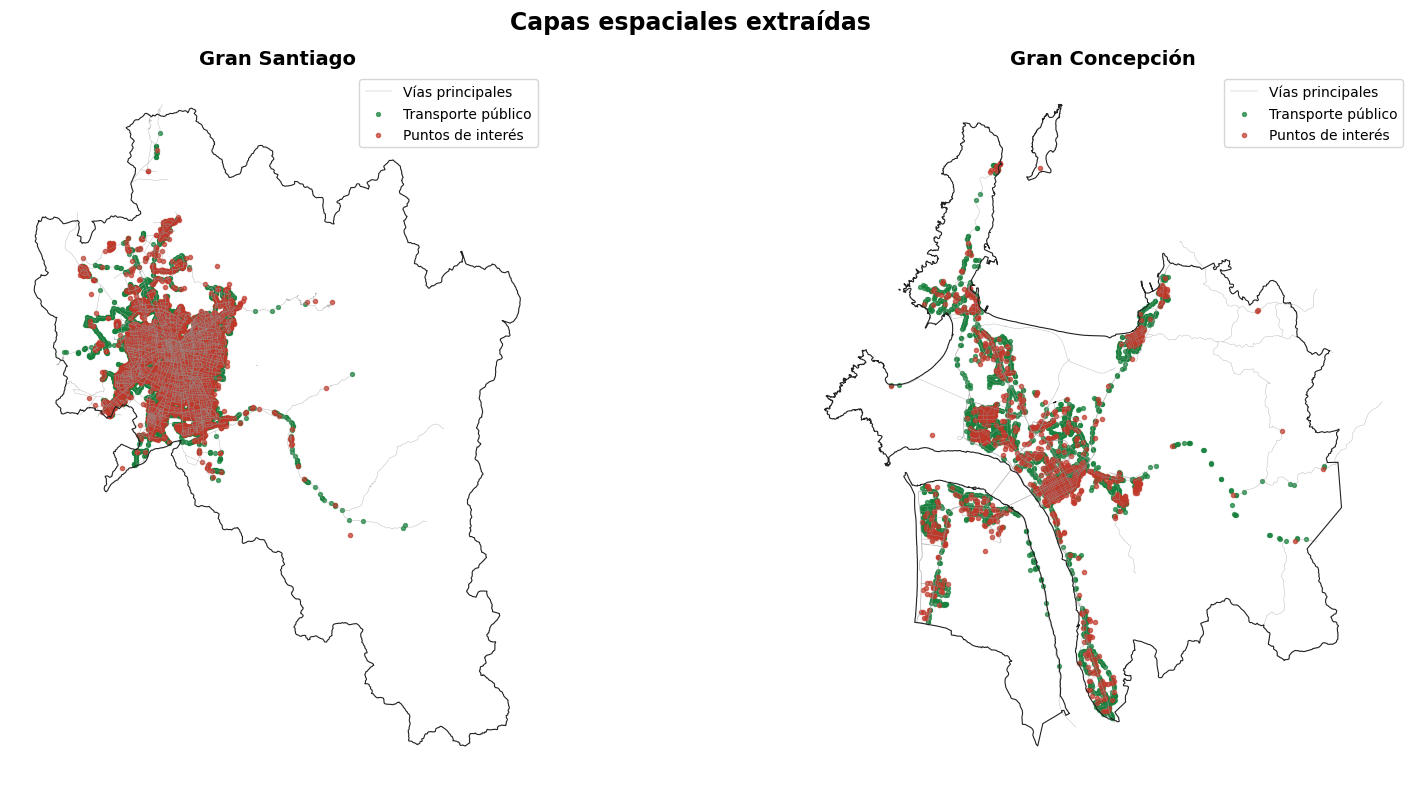

In [4]:
fig, ejes = plt.subplots(1, 2, figsize=(18, 8))

for (ciudad, capas), ax in zip(capas_ciudad.items(), ejes):
    if not capas["vias"].empty:
        capas["vias"].plot(
            ax=ax, color="#9a9a9a", linewidth=0.35, alpha=0.65, label="Vías principales"
        )
    if not capas["transporte"].empty:
        capas["transporte"].plot(
            ax=ax, color="#16803c", markersize=8, alpha=0.7, label="Transporte público"
        )
    if not capas["pois"].empty:
        capas["pois"].plot(
            ax=ax, color="#c0392b", markersize=9, alpha=0.7, label="Puntos de interés"
        )

    borde = gpd.GeoSeries([CIUDADES[ciudad]["mascara"]], crs="EPSG:4326")
    borde.boundary.plot(ax=ax, color="#222222", linewidth=0.8)
    ax.set_title(ciudad, fontsize=14, fontweight="bold")
    ax.set_axis_off()
    ax.legend(loc="best")

fig.suptitle("Capas espaciales extraídas", fontsize=17, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Grilla y variables por celda

En ambas ciudades se construye una grilla de 250 m. Cada celda recibe el indicador de presencia de supermercados, conteos de transporte público y conteos separados por categorí­a de punto de interés.

In [5]:
def construir_grilla(config, capas):
    crs_utm = config["crs_utm"]
    mascara_utm = gpd.GeoSeries(
        [config["mascara"]], crs="EPSG:4326"
    ).to_crs(crs_utm).iloc[0]

    xmin, ymin, xmax, ymax = mascara_utm.bounds
    celdas = [
        box(x, y, x + tamano_celda, y + tamano_celda)
        for x in np.arange(xmin, xmax, tamano_celda)
        for y in np.arange(ymin, ymax, tamano_celda)
    ]
    grilla = gpd.GeoDataFrame({"geometry": celdas}, crs=crs_utm)
    grilla = gpd.clip(grilla, mascara_utm).reset_index(drop=True)
    grilla["id_celda"] = grilla.index
    ids = grilla["id_celda"]

    pois = capas["pois"].to_crs(crs_utm)
    supermercados = pois[pois["fclass"] == "supermarket"]
    cruce_supermercados = gpd.sjoin(
        grilla, supermercados, how="left", predicate="intersects"
    )
    supermercados_por_celda = (
        cruce_supermercados.groupby("id_celda")["fclass"]
        .count()
        .reindex(ids, fill_value=0)
    )
    grilla["target_supermercado"] = supermercados_por_celda.gt(0).astype("int8").to_numpy()

    transporte = capas["transporte"].to_crs(crs_utm)
    cruce_transporte = gpd.sjoin(
        grilla, transporte, how="left", predicate="intersects"
    )
    grilla["conteo_paraderos"] = (
        cruce_transporte.groupby("id_celda")["fclass"]
        .count()
        .reindex(ids, fill_value=0)
        .to_numpy()
    )

    predictores = pois[pois["fclass"].isin(CATEGORIAS_PREDICTORAS)]
    cruce_pois = gpd.sjoin(
        grilla, predictores, how="left", predicate="intersects"
    )
    conteos = (
        cruce_pois.groupby(["id_celda", "fclass"]).size()
        .unstack(fill_value=0)
        .reindex(index=ids, columns=CATEGORIAS_PREDICTORAS, fill_value=0)
    )
    conteos.columns = [f"conteo_{categoria}" for categoria in conteos.columns]
    grilla = grilla.join(conteos, on="id_celda")

    return grilla, mascara_utm


grillas_ciudad = {}
datasets_ciudad = {}

for ciudad, config in CIUDADES.items():
    grilla, _ = construir_grilla(config, capas_ciudad[ciudad])
    grillas_ciudad[ciudad] = grilla
    dataset = grilla.drop(columns="geometry").copy()
    ruta_salida = os.path.join(ruta_processed, f"dataset_entrenamiento_{config['prefijo']}.csv")
    dataset.to_csv(ruta_salida, index=False)
    datasets_ciudad[ciudad] = dataset
    print(f"{ciudad}: {len(grilla)} celdas; dataset guardado en {ruta_salida}.")

Gran Santiago: 148911 celdas; dataset guardado en data\processed\dataset_entrenamiento_stgo.csv.
Gran Concepción: 10501 celdas; dataset guardado en data\processed\dataset_entrenamiento_ccp.csv.


## 5. Integracion y verificacion del Censo 2024

Se asigna la poblacion `n_per` de cada manzana a la celda que contiene el centroide de la manzana original. El centroide se calcula en UTM antes de recortar, y se informa el total dentro de cada mascara, lo asignado a la grilla y la poblacion por comuna.

In [6]:
censo_manzanas = gpd.read_parquet(ruta_censo)
if "n_per" not in censo_manzanas.columns:
    raise KeyError("No se encontro la columna 'n_per' en las manzanas del Censo.")
if censo_manzanas.crs is None:
    raise ValueError("Las manzanas censales no tienen un CRS definido.")
if "COMUNA" not in censo_manzanas.columns:
    raise KeyError("No se encontro la columna 'COMUNA' en las manzanas del Censo.")
censo_manzanas["n_per"] = pd.to_numeric(censo_manzanas["n_per"], errors="raise")
print(f"Total nacional en el archivo de manzanas censales: {censo_manzanas['n_per'].sum():,.0f} habitantes.")

for ciudad, config in CIUDADES.items():
    grilla = grillas_ciudad[ciudad]
    mascara_utm = gpd.GeoSeries(
        [config["mascara"]], crs="EPSG:4326"
    ).to_crs(config["crs_utm"]).iloc[0]

    # Mantener la geometria original al calcular el centroide evita desplazar
    # las manzanas que cruzan el limite de la mascara.
    censo_centroides = censo_manzanas.to_crs(config["crs_utm"]).copy()
    censo_centroides = censo_centroides.set_geometry(
        censo_centroides.geometry.centroid
    )
    censo_ciudad = censo_centroides[
        censo_centroides.geometry.within(mascara_utm)
    ].copy()

    cruce_censo = gpd.sjoin(
        censo_ciudad,
        grilla[["id_celda", "geometry"]],
        how="left",
        predicate="within",
    )
    tiene_celda = cruce_censo["index_right"].notna()
    personas_en_mascara = censo_ciudad["n_per"].sum()
    personas_asignadas = cruce_censo.loc[tiene_celda, "n_per"].sum()
    personas_sin_celda = cruce_censo.loc[~tiene_celda, "n_per"].sum()

    poblacion = (
        cruce_censo.loc[tiene_celda]
        .groupby("id_celda")["n_per"]
        .sum()
        .reindex(grilla["id_celda"], fill_value=0)
    )
    grilla["densidad_poblacion"] = poblacion.to_numpy()
    datasets_ciudad[ciudad] = grilla.drop(columns="geometry").copy()

    ruta_salida = os.path.join(ruta_processed, f"dataset_entrenamiento_{config['prefijo']}.csv")
    datasets_ciudad[ciudad].to_csv(ruta_salida, index=False)
    print(
        f"{ciudad}: {personas_en_mascara:,.0f} habitantes en la mascara; "
        f"{personas_asignadas:,.0f} asignados a la grilla; "
        f"{personas_sin_celda:,.0f} sin celda."
    )
    resumen_comunas = (
        censo_ciudad.groupby("COMUNA")["n_per"]
        .sum()
        .sort_values(ascending=False)
        .rename("habitantes")
        .to_frame()
    )
    print(f"Poblacion censal incluida por comuna ({ciudad}):")
    display(resumen_comunas)

Total nacional en el archivo de manzanas censales: 16,185,953 habitantes.
Gran Santiago: 6,532,737 habitantes en la mascara; 6,532,737 asignados a la grilla; 0 sin celda.
Poblacion censal incluida por comuna (Gran Santiago):


,habitantes
COMUNA,
PUENTE ALTO,560695.0
MAIPÚ,496347.0
SANTIAGO,432081.0
LA FLORIDA,371110.0
SAN BERNARDO,296664.0
LAS CONDES,292863.0
ÑUÑOA,239730.0
PEÑALOLÉN,232654.0
PUDAHUEL,221269.0


Gran Concepción: 742,804 habitantes en la mascara; 742,804 asignados a la grilla; 0 sin celda.
Poblacion censal incluida por comuna (Gran Concepción):


,habitantes
COMUNA,
CONCEPCIÓN,226016.0
SAN PEDRO DE LA PAZ,150512.0
TALCAHUANO,145379.0
HUALPÉN,87097.0
CHIGUAYANTE,85641.0
PENCO,48159.0


## 6. Estadisticas descriptivas

Para cada ciudad se presentan las estadisticas del dataset ya integrado con el Censo 2024, las cinco celdas con mas poblacion y los totales de supermercados, las categorias individuales de puntos de interes comerciales, nodos de transporte y habitantes.

In [7]:
for ciudad, dataset in datasets_ciudad.items():
    print(f"\n### {ciudad}: resumen estadístico")
    display(dataset.describe().T)

    print(f"Cinco celdas con más población en {ciudad}:")
    display(
        dataset.sort_values("densidad_poblacion", ascending=False)
        .head(5)
    )

    columnas_totales = [
        "target_supermercado",
        "conteo_paraderos",
        *[f"conteo_{categoria}" for categoria in CATEGORIAS_COMERCIALES],
        "densidad_poblacion",
    ]
    print(f"Totales en {ciudad}:")
    display(dataset[columnas_totales].sum().rename("total"))


### Gran Santiago: resumen estadístico


,count,mean,std,min,25%,50%,75%,max
id_celda,148911.0,74455.000000,42987.047305,0.0,37227.5,74455.0,111682.5,148910.0
target_supermercado,148911.0,0.003264,0.057036,0.0,0.0,0.0,0.0,1.0
conteo_paraderos,148911.0,0.083379,0.465337,0.0,0.0,0.0,0.0,9.0
conteo_convenience,148911.0,0.014022,0.169945,0.0,0.0,0.0,0.0,9.0
conteo_mall,148911.0,0.001021,0.035517,0.0,0.0,0.0,0.0,3.0
conteo_pharmacy,148911.0,0.008354,0.138237,0.0,0.0,0.0,0.0,9.0
conteo_marketplace,148911.0,0.000665,0.030545,0.0,0.0,0.0,0.0,4.0
conteo_school,148911.0,0.020442,0.182024,0.0,0.0,0.0,0.0,6.0
conteo_university,148911.0,0.001417,0.056817,0.0,0.0,0.0,0.0,9.0
conteo_college,148911.0,0.000497,0.025120,0.0,0.0,0.0,0.0,4.0


Cinco celdas con más población en Gran Santiago:


,id_celda,target_supermercado,conteo_paraderos,conteo_convenience,conteo_mall,conteo_pharmacy,conteo_marketplace,conteo_school,conteo_university,conteo_college,conteo_hospital,conteo_clinic,conteo_sports_centre,densidad_poblacion
29579,29579,0,0,0,0,0,0,2,0,0,0,0,0,11743.0
29496,29496,0,0,0,0,0,0,0,0,0,1,0,0,10434.0
30488,30488,0,1,1,0,0,0,1,0,0,0,0,0,9937.0
29729,29729,0,4,1,0,1,0,0,0,0,0,0,0,7753.0
29589,29589,0,1,0,0,0,0,0,0,0,0,0,0,6539.0


Totales en Gran Santiago:


...

,count,mean,std,min,25%,50%,75%,max
id_celda,10501.0,5250.000000,3031.521923,0.0,2625.0,5250.0,7875.0,10500.0
target_supermercado,10501.0,0.011427,0.106292,0.0,0.0,0.0,0.0,1.0
conteo_paraderos,10501.0,0.207790,0.751925,0.0,0.0,0.0,0.0,8.0
conteo_convenience,10501.0,0.031902,0.278484,0.0,0.0,0.0,0.0,6.0
conteo_mall,10501.0,0.002285,0.060115,0.0,0.0,0.0,0.0,4.0
conteo_pharmacy,10501.0,0.012856,0.226204,0.0,0.0,0.0,0.0,15.0
conteo_marketplace,10501.0,0.000857,0.032356,0.0,0.0,0.0,0.0,2.0
conteo_school,10501.0,0.035235,0.222745,0.0,0.0,0.0,0.0,5.0
conteo_university,10501.0,0.002476,0.058502,0.0,0.0,0.0,0.0,3.0
conteo_college,10501.0,0.001428,0.042515,0.0,0.0,0.0,0.0,2.0


Cinco celdas con más población en Gran Concepción:


,id_celda,target_supermercado,conteo_paraderos,conteo_convenience,conteo_mall,conteo_pharmacy,conteo_marketplace,conteo_school,conteo_university,conteo_college,conteo_hospital,conteo_clinic,conteo_sports_centre,densidad_poblacion
1055,1055,0,1,0,0,0,0,0,0,0,0,0,0,3256.0
2306,2306,0,0,0,0,0,0,0,0,0,0,0,0,3218.0
2095,2095,0,0,0,0,0,0,0,0,0,0,0,0,2839.0
2098,2098,0,0,0,0,0,0,0,0,0,0,0,0,2559.0
990,990,0,0,0,0,0,0,0,0,0,0,0,0,2397.0


Totales en Gran Concepción:


target_supermercado       120.0
conteo_paraderos         2182.0
conteo_convenience        335.0
conteo_mall                24.0
conteo_pharmacy           135.0
conteo_marketplace          9.0
densidad_poblacion     742804.0
Name: total, dtype: float64

## 7. Correlaciones

Se calcula y grafica la matriz de correlacion de todas las variables numericas de cada ciudad, incluida la poblacion, excluyendo el identificador de celda.

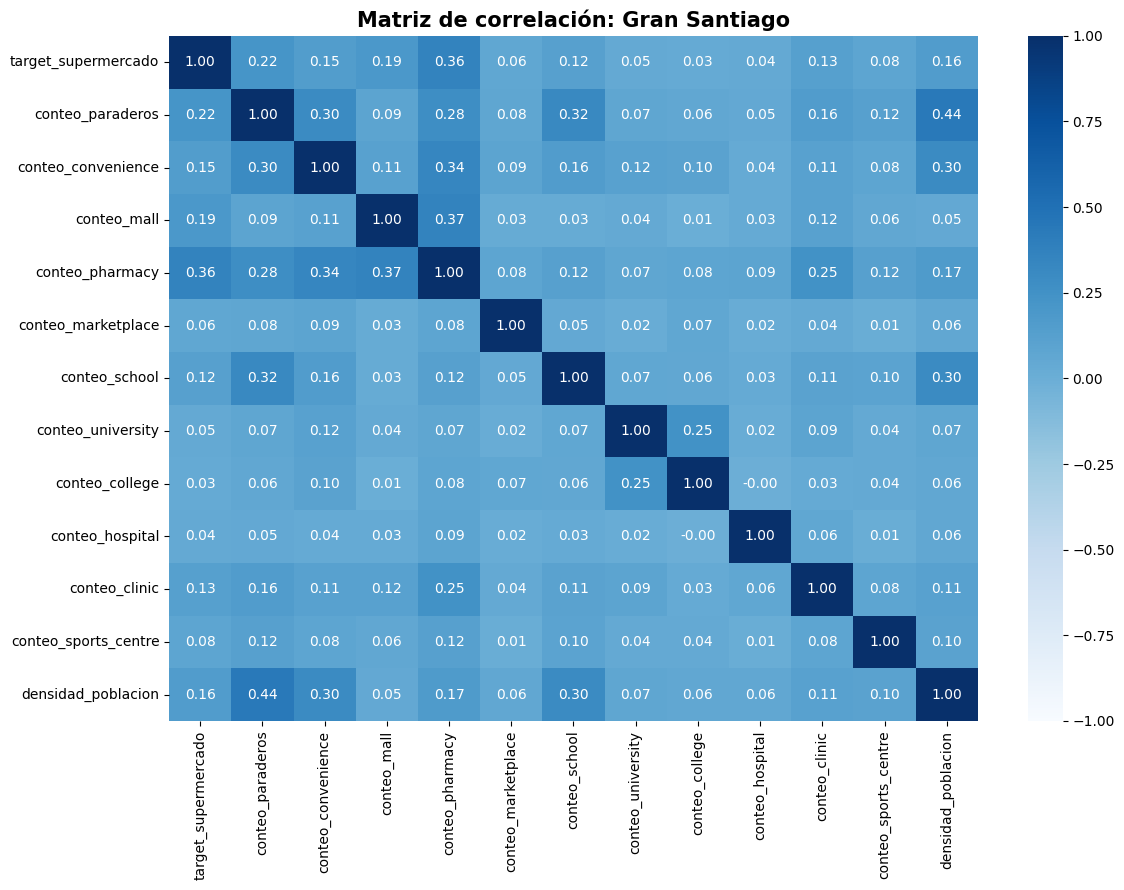

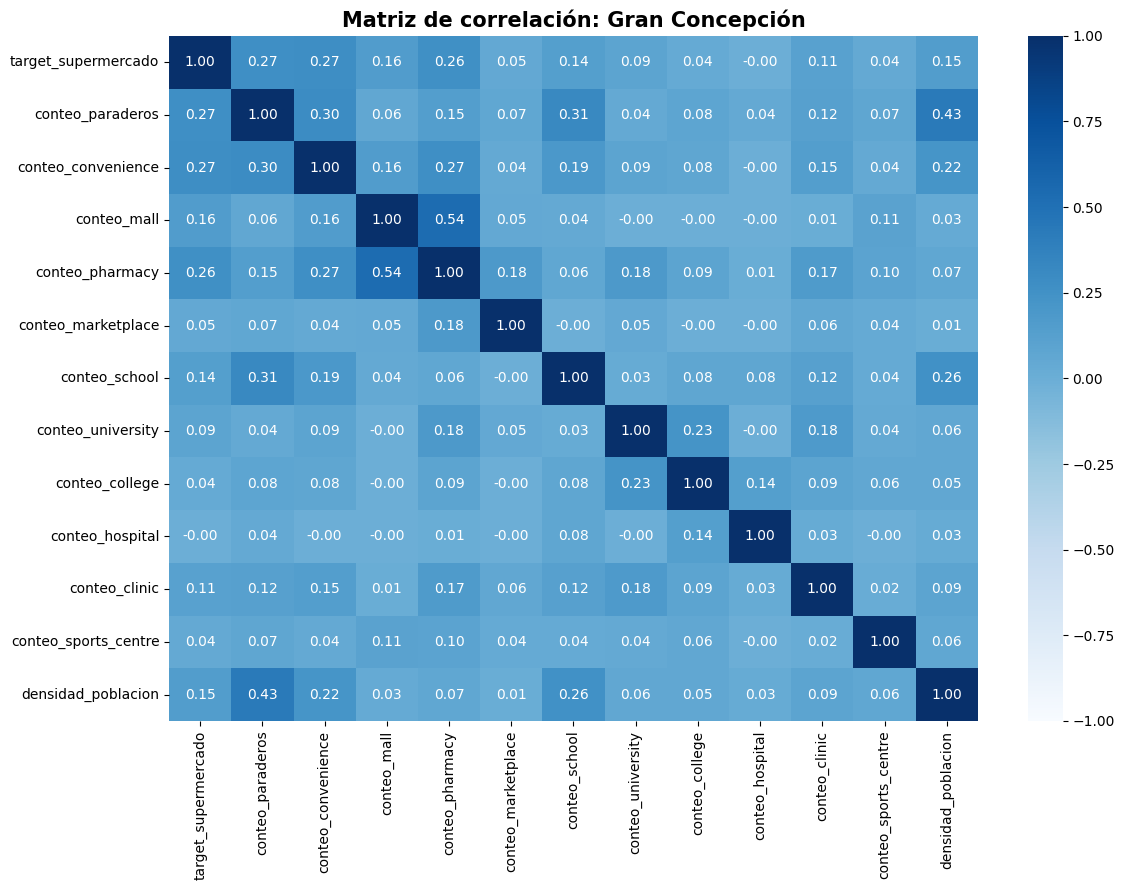

In [8]:
for ciudad, dataset in datasets_ciudad.items():
    columnas = [col for col in dataset.columns if col != "id_celda"]
    correlaciones = dataset[columnas].corr()

    fig, ax = plt.subplots(figsize=(12, 9))
    sns.heatmap(
        correlaciones,
        annot=True,
        cmap="Blues",
        vmin=-1,
        vmax=1,
        fmt=".2f",
        ax=ax,
    )
    ax.set_title(f"Matriz de correlación: {ciudad}", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()

## 8. Distribucion y mapa de poblacion

Los mapas de poblacion muestran solo celdas habitadas para centrar la vista en las zonas urbanas. En el mapa de Gran Santiago se omite visualmente Lo Barnechea por su gran superficie de baja densidad. Estos filtros afectan unicamente a los mapas: los histogramas, CSV y totales conservan todas las comunas y celdas. Cada ciudad se guarda como SVG vectorial y PNG a 400 dpi en `resultados/poblacion`.

Gran Santiago: 9,301 celdas mostradas en el mapa de 148,911 celdas; graficos guardados como SVG y PNG.


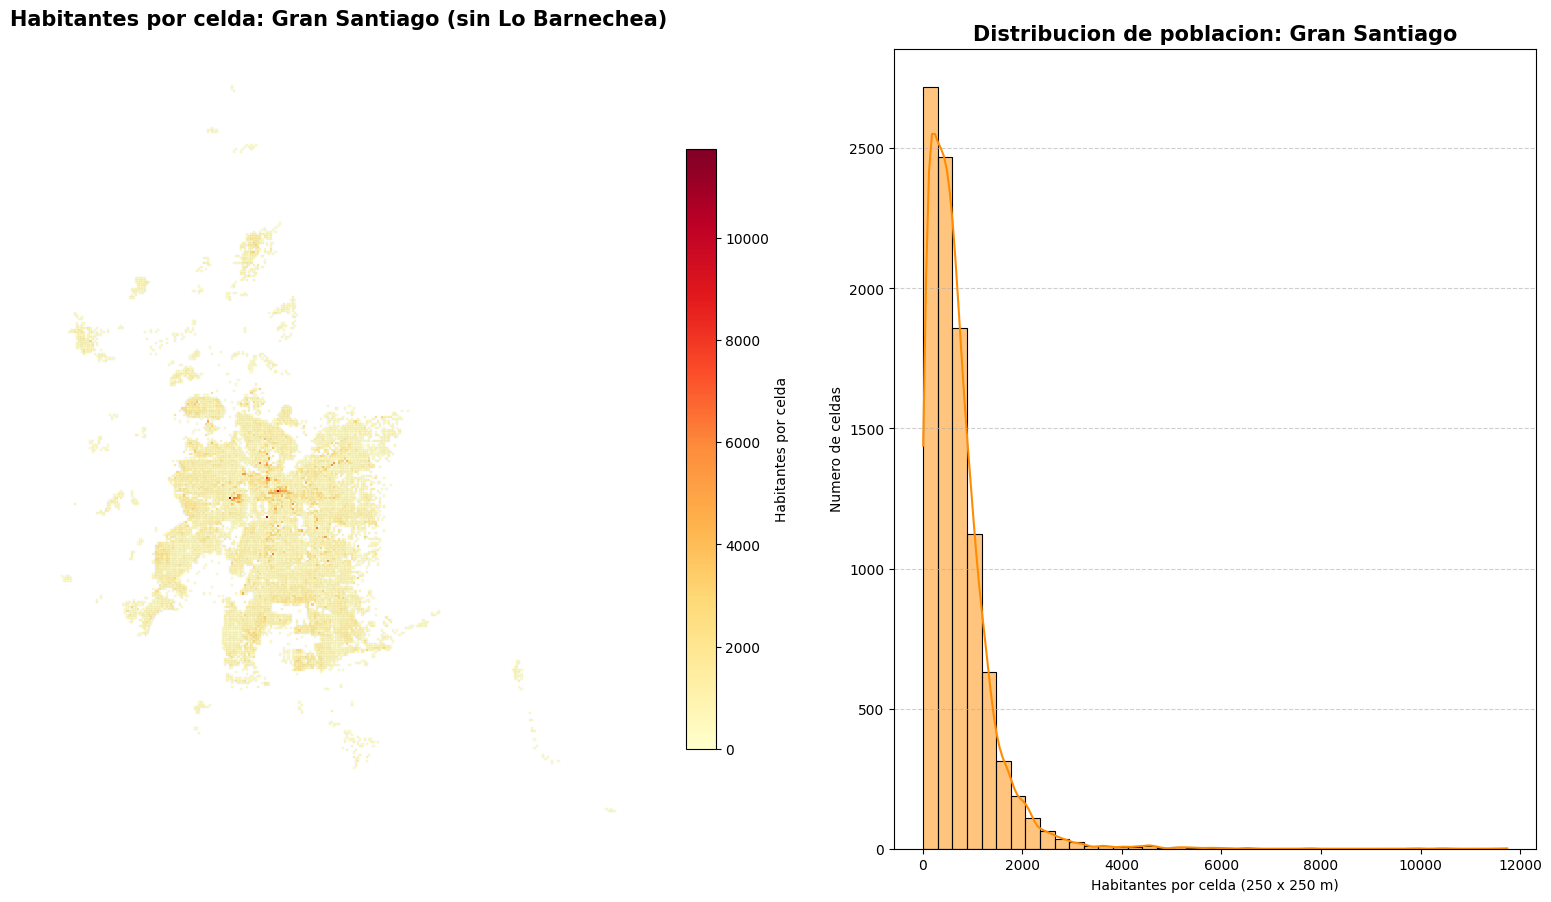

Gran Concepción: 1,630 celdas mostradas en el mapa de 10,501 celdas; graficos guardados como SVG y PNG.


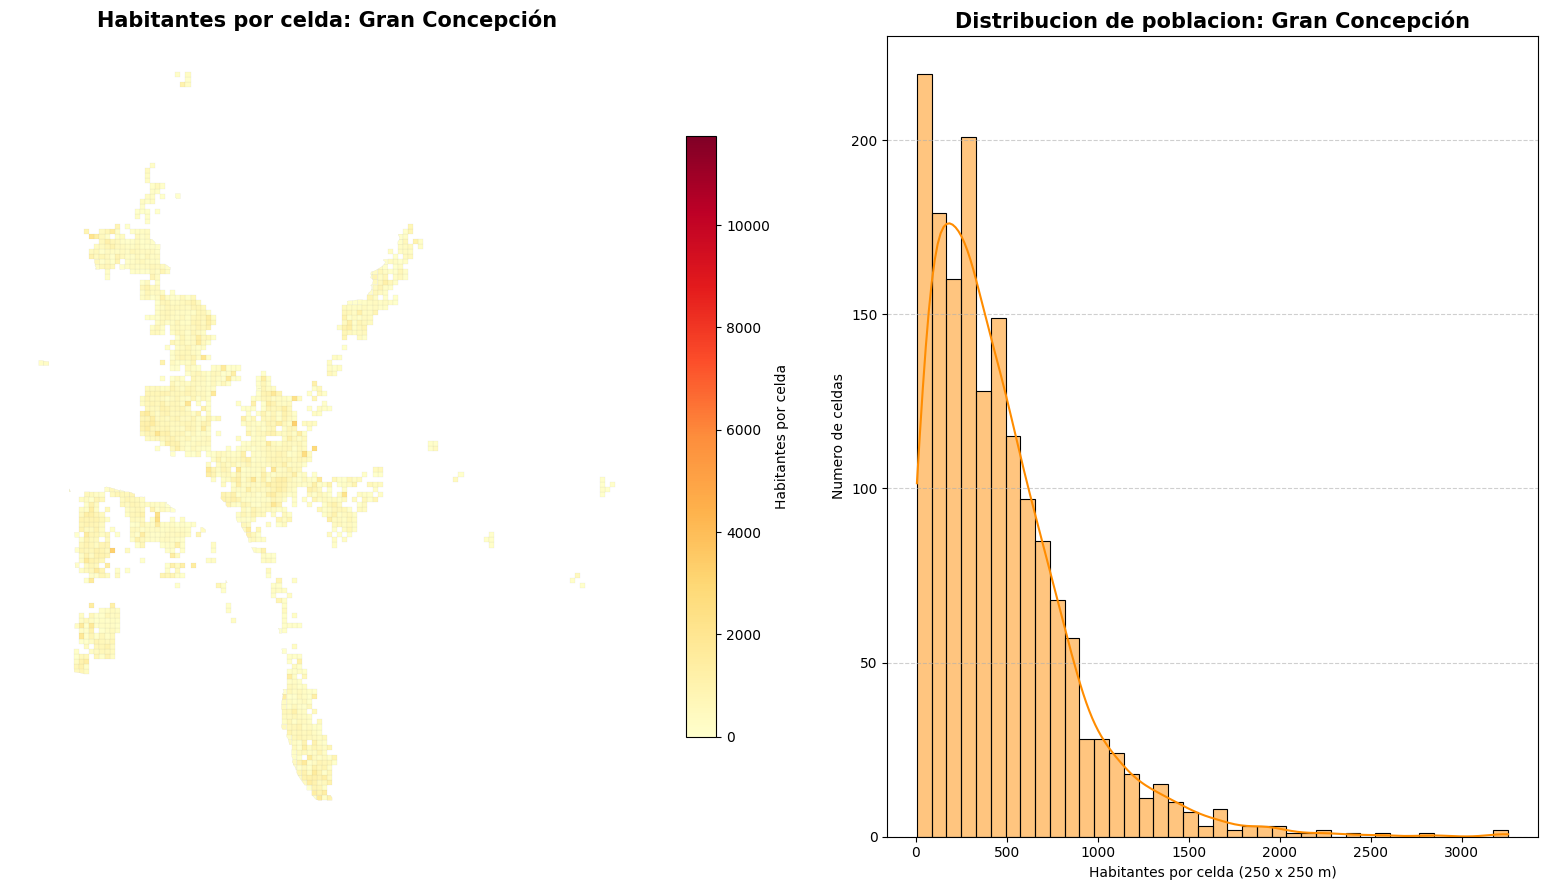

In [9]:
# Este recorte solo afecta el mapa; los CSV, histogramas y totales usan la grilla completa.
comuna_excluida_santiago = comunas.loc[
    comunas["comuna_normalizada"] == "LO BARNECHEA"
].copy()
if len(comuna_excluida_santiago) != 1:
    raise ValueError("No se pudo identificar de forma unica la comuna de Lo Barnechea.")

vmax_poblacion = max(
    grilla["densidad_poblacion"].max() for grilla in grillas_ciudad.values()
)
ruta_graficos = os.path.join("resultados", "poblacion")
os.makedirs(ruta_graficos, exist_ok=True)

for ciudad, grilla in grillas_ciudad.items():
    fig, (ax_mapa, ax_histograma) = plt.subplots(
        1,
        2,
        figsize=(16, 9),
        gridspec_kw={"width_ratios": [1.3, 1]},
    )

    celdas_visibles = grilla["densidad_poblacion"] > 0
    if ciudad == "Gran Santiago":
        lo_barnechea = comuna_excluida_santiago.to_crs(grilla.crs).geometry.union_all()
        puntos_representativos = grilla.geometry.representative_point()
        celdas_visibles &= ~puntos_representativos.within(lo_barnechea)

    grilla_mapa = grilla.loc[celdas_visibles].copy()
    if grilla_mapa.empty:
        raise ValueError(f"No hay celdas pobladas para mostrar en {ciudad}.")

    grilla_mapa.plot(
        column="densidad_poblacion",
        ax=ax_mapa,
        cmap="YlOrRd",
        vmin=0,
        vmax=vmax_poblacion,
        legend=True,
        legend_kwds={
            "label": "Habitantes por celda",
            "shrink": 0.75,
        },
        edgecolor="#808080",
        linewidth=0.04,
    )
    if ciudad == "Gran Santiago":
        titulo_mapa = "Habitantes por celda: Gran Santiago (sin Lo Barnechea)"
    else:
        titulo_mapa = f"Habitantes por celda: {ciudad}"
    ax_mapa.set_title(titulo_mapa, fontsize=15, fontweight="bold")
    ax_mapa.set_axis_off()

    celdas_pobladas = grilla.loc[
        grilla["densidad_poblacion"] > 0,
        "densidad_poblacion",
    ]
    sns.histplot(
        celdas_pobladas,
        bins=40,
        kde=True,
        color="darkorange",
        ax=ax_histograma,
    )
    ax_histograma.set_title(
        f"Distribucion de poblacion: {ciudad}",
        fontsize=15,
        fontweight="bold",
    )
    ax_histograma.set_xlabel(
        f"Habitantes por celda ({tamano_celda} x {tamano_celda} m)"
    )
    ax_histograma.set_ylabel("Numero de celdas")
    ax_histograma.grid(axis="y", linestyle="--", alpha=0.6)

    fig.tight_layout()
    prefijo = CIUDADES[ciudad]["prefijo"]
    ruta_base = os.path.join(ruta_graficos, f"poblacion_{prefijo}")
    fig.savefig(f"{ruta_base}.svg", format="svg", bbox_inches="tight")
    fig.savefig(
        f"{ruta_base}.png",
        format="png",
        dpi=400,
        bbox_inches="tight",
        facecolor="white",
    )
    print(
        f"{ciudad}: {len(grilla_mapa):,} celdas mostradas en el mapa "
        f"de {len(grilla):,} celdas; graficos guardados como SVG y PNG."
    )
    plt.show()
    plt.close(fig)